# Multi-Objective Optimization

This tutorial shows how `discopt.mo` wraps discopt's single-objective MINLP
solver in classical scalarization loops, producing a
`ParetoFront` approximation for problems with two or more conflicting
objectives.

A multi-objective problem replaces a single scalar objective with a vector
$F(x) = (f_1(x), \ldots, f_k(x))$. In general no $x$ minimizes every
$f_i$ simultaneously; the solution concept is the *Pareto front* -- the
set of trade-offs where improving one objective requires worsening another
{cite:p}`miettinen-1999` {cite:p}`ehrgott-2005`.

`discopt.mo` exposes five deterministic scalarization methods:

| Method | API | Complete on nonconvex fronts? |
|--------|-----|-------------------------------|
| Weighted sum | `weighted_sum` | No {cite:p}`marler-arora-2004` |
| AUGMECON2 $\varepsilon$-constraint | `epsilon_constraint` | Yes {cite:p}`mavrotas-2009` |
| Augmented weighted Tchebycheff | `weighted_tchebycheff` | Yes {cite:p}`steuer-choo-1983` |
| Normal Boundary Intersection | `normal_boundary_intersection` | Yes {cite:p}`das-dennis-1998` |
| Normalized Normal Constraint | `normalized_normal_constraint` | Yes {cite:p}`messac-2003` |

Each returns a `ParetoFront` carrying the Pareto points, ideal/nadir
estimates, sense information, and helpers for indicators and plotting.


In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import discopt.modeling as dm
import matplotlib.pyplot as plt
import numpy as np
from discopt.mo import (
    epsilon_constraint,
    normal_boundary_intersection,
    normalized_normal_constraint,
    weighted_sum,
    weighted_tchebycheff,
)

## 1. A convex bi-objective MINLP

We start with the canonical bi-objective convex QP

$$
\min f_1 = x^2 + y^2, \quad \min f_2 = (x-2)^2 + (y-1)^2,
\qquad x, y \in [-5, 5].
$$

The Pareto front has the closed form $\sqrt{f_1/5} + \sqrt{f_2/5} = 1$
and is *convex*, so every scalarization should recover it.


In [2]:
def build_convex_qp():
    m = dm.Model("biobj_qp")
    x = m.continuous("x", lb=-5, ub=5)
    y = m.continuous("y", lb=-5, ub=5)
    f1 = x**2 + y**2
    f2 = (x - 2) ** 2 + (y - 1) ** 2
    return m, [f1, f2]


# Analytic front for reference plotting.
alpha = np.linspace(0, 1, 101)
ref_f1 = 5 * alpha**2
ref_f2 = 5 * (1 - alpha) ** 2

### 1.1 Weighted sum

The simplest scalarization is a convex combination
$\min \sum_i w_i f_i(x)$ with $w$ ranging over the simplex. It recovers
every Pareto point on a *convex* front but misses concave pieces.

In [3]:
m, objs = build_convex_qp()
front_ws = weighted_sum(m, objs, n_weights=11)
print(front_ws.summary())

Pareto Front (weighted_sum, 11 points, k=2)
  ideal: f1=0, f2=1.332e-14
  nadir: f1=5, f2=5

            f1            f2
  ------------  ------------
             5     3.125e-13
          4.05     0.0500002
           3.2           0.2
          2.45      0.450001
           1.8      0.800001
          1.25          1.25
           0.8           1.8
          0.45          2.45
           0.2           3.2
          0.05          4.05
             0             5


### 1.2 AUGMECON2 ($\varepsilon$-constraint)

Minimize one objective; bound the others by $\varepsilon_i$ parameters.
The *augmented* form (default) adds a non-negative slack per bound and a
small slack-reward penalty so every returned point is strictly Pareto-
optimal {cite:p}`mavrotas-2009`.

In [4]:
m, objs = build_convex_qp()
front_eps = epsilon_constraint(m, objs, n_points=11)
print(front_eps.summary())


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Pareto Front (augmecon2, 11 points, k=2)
  ideal: f1=0, f2=1.332e-14
  nadir: f1=5, f2=5

            f1            f2
  ------------  ------------
       4.99937   1.99997e-08
       2.33772           0.5
       1.52786             1
       1.02277           1.5
      0.675445             2
      0.428932           2.5
      0.254033             3
        0.1334           3.5
     0.0557281             4
      0.013167           4.5
   2.01766e-07       4.99799


### 1.3 Weighted Tchebycheff

Minimize the $L_\infty$ distance from the ideal point under weights $w$:

$$
\min \max_i\ w_i (f_i(x) - z^*_i) \quad\text{plus a small slack penalty.}
$$

Unlike weighted sum, every Pareto-optimal point is attainable for some
$w$, *with no convexity assumption* {cite:p}`steuer-choo-1983`.

In [5]:
m, objs = build_convex_qp()
front_tch = weighted_tchebycheff(m, objs, n_weights=11)
print(front_tch.summary())

Pareto Front (weighted_tchebycheff, 11 points, k=2)
  ideal: f1=0, f2=1.332e-14
  nadir: f1=5, f2=5

            f1            f2
  ------------  ------------
             5   6.79531e-18
        2.8125        0.3125
       2.22222      0.555556
       1.82623      0.782671
       1.51531       1.01021
          1.25          1.25
       1.01021       1.51531
      0.782671       1.82623
      0.555556       2.22222
        0.3125        2.8125
   1.23991e-41             5


### 1.4 NBI and NNC

Normal Boundary Intersection {cite:p}`das-dennis-1998` and the Normalized
Normal Constraint method {cite:p}`messac-2003` are *geometric*
scalarizations designed for uniform spacing of the returned points along
the front, irrespective of curvature.

In [6]:
m, objs = build_convex_qp()
front_nbi = normal_boundary_intersection(m, objs, n_points=11)

m, objs = build_convex_qp()
front_nnc = normalized_normal_constraint(m, objs, n_points=11)

print("NBI:", front_nbi.n, "points,  NNC:", front_nnc.n, "points")

NBI: 11 points,  NNC: 11 points


### 1.5 Compare all five methods

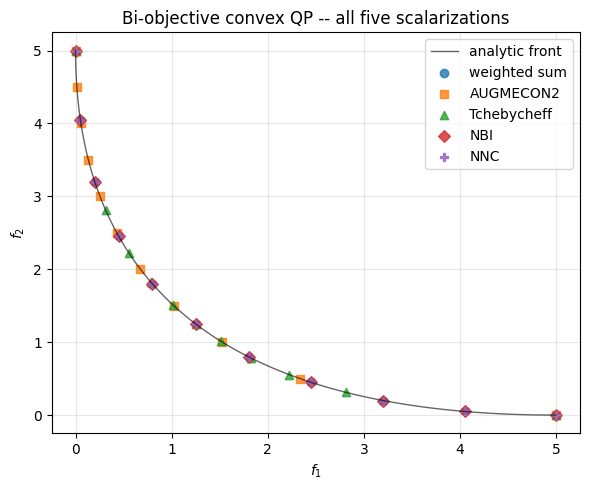

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(ref_f1, ref_f2, "k-", lw=1, alpha=0.6, label="analytic front")
for name, front, marker in [
    ("weighted sum", front_ws, "o"),
    ("AUGMECON2", front_eps, "s"),
    ("Tchebycheff", front_tch, "^"),
    ("NBI", front_nbi, "D"),
    ("NNC", front_nnc, "P"),
]:
    obj = front.objectives()
    ax.scatter(obj[:, 0], obj[:, 1], marker=marker, label=name, alpha=0.8)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$")
ax.set_title("Bi-objective convex QP -- all five scalarizations")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout();

## 2. Hypervolume comparison

The hypervolume indicator is the Lebesgue measure of the region dominated
by a front with respect to a reference point (chosen beyond the nadir). It
is Pareto-compliant -- a front that dominates another has strictly larger
hypervolume -- so it is the standard scalar quality measure
{cite:p}`zitzler-deb-thiele-2000`.

In [8]:
ref = np.array([5.5, 5.5])
rows = []
for name, f in [
    ("weighted_sum", front_ws),
    ("augmecon2", front_eps),
    ("tchebycheff", front_tch),
    ("nbi", front_nbi),
    ("nnc", front_nnc),
]:
    rows.append((name, f.n, f.hypervolume(reference=ref)))
for name, n, hv in rows:
    print(f"  {name:>14s}   n={n:3d}   hypervolume = {hv:.4f}")

    weighted_sum   n= 11   hypervolume = 25.1625
       augmecon2   n= 11   hypervolume = 24.5258
     tchebycheff   n= 11   hypervolume = 24.7531
             nbi   n= 11   hypervolume = 25.1625
             nnc   n= 11   hypervolume = 25.1625


## 3. A nonconvex front

When the Pareto front is concave, the image set is *not* convex and
weighted sum fails: for every $w \ge 0$ the minimum is attained at an
anchor, not in the front's interior. AUGMECON2, Tchebycheff, NBI, and NNC
all recover the full front.

$$
\min f_1 = x, \quad \min f_2 = y,\qquad x^2 + y^2 \ge 1, \quad x, y \in [0, 1].
$$

The Pareto boundary is the quarter-arc of the unit circle, which is
strictly concave.

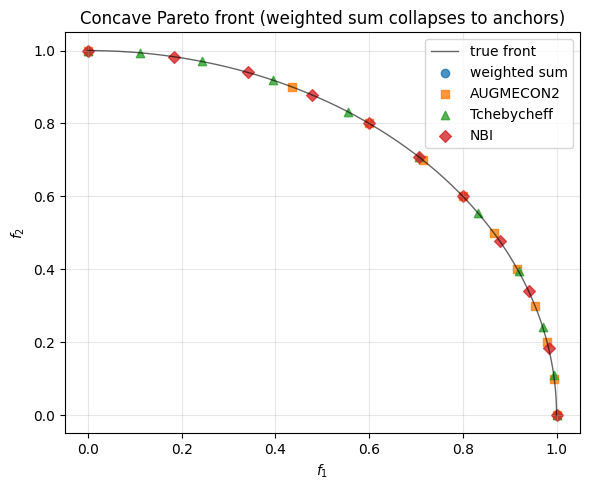

In [9]:
def build_concave():
    m = dm.Model("concave")
    x = m.continuous("x", lb=0, ub=1)
    y = m.continuous("y", lb=0, ub=1)
    m.subject_to(x**2 + y**2 >= 1.0)
    return m, [x, y]


m, objs = build_concave()
c_ws = weighted_sum(m, objs, n_weights=11)
m, objs = build_concave()
c_tch = weighted_tchebycheff(m, objs, n_weights=11)
m, objs = build_concave()
c_eps = epsilon_constraint(m, objs, n_points=11)
m, objs = build_concave()
c_nbi = normal_boundary_intersection(m, objs, n_points=11)

fig, ax = plt.subplots(figsize=(6, 5))
theta = np.linspace(0, np.pi / 2, 201)
ax.plot(np.cos(theta), np.sin(theta), "k-", lw=1, alpha=0.6, label="true front")
for name, f, marker in [
    ("weighted sum", c_ws, "o"),
    ("AUGMECON2", c_eps, "s"),
    ("Tchebycheff", c_tch, "^"),
    ("NBI", c_nbi, "D"),
]:
    obj = f.objectives()
    ax.scatter(obj[:, 0], obj[:, 1], marker=marker, label=name, alpha=0.8)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$")
ax.set_title("Concave Pareto front (weighted sum collapses to anchors)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout();

## 4. When to use which method

Synthesis of the guidance in {cite:p}`miettinen-1999` and
{cite:p}`marler-arora-2004`:

| Goal | Method |
|------|--------|
| Convex front, simple baseline | `weighted_sum` |
| Guaranteed completeness on any front | `epsilon_constraint` (AUGMECON2) |
| Nonconvex front, $L_\infty$ semantics | `weighted_tchebycheff` |
| Uniform spacing, smooth convex front | `normal_boundary_intersection` |
| Robust geometric method with explicit normalization | `normalized_normal_constraint` |

All methods share the same calling convention: pass the `Model`, the list
of objective `Expression` objects, optional `senses=["min", ..., "max"]`,
and any `solve_kwargs` (e.g. `time_limit=`, `gap_tolerance=`). The
returned `ParetoFront` supports `.summary()`, `.plot()`,
`.hypervolume(reference=...)`, and `.filtered()` (strict-nondominance
filter).

## 5. Side effects

Scalarizers **mutate** the input `Model`: auxiliary parameters (and, for
AUGMECON, Tchebycheff, NBI, NNC, extra variables and constraints) are
added. The model's original objective is restored on exit, but residual
auxiliary structure remains. If you intend to reuse the model for other
solves, build a fresh `dm.Model` each call. This matches the in-place
pattern used by `discopt.ro`.

## 6. Next steps

- For *expensive* objectives (each evaluation costs minutes or requires
  lab experiments) see the upcoming Bayesian multi-objective wrapper
  based on expected hypervolume improvement {cite:p}`knowles-2006`.
- For **evolutionary** multi-objective algorithms (NSGA-II, MOEA/D,
  NSGA-III) use `pymoo` {cite:p}`blank-deb-2020` to generate baseline
  fronts, then refine with a `discopt.mo` scalarization sweep.
- The full algorithmic background is in the `.crucible/wiki/methods/`
  articles shipped with the repo.
